In [1]:
%pylab inline
%load_ext autoreload
%autoreload 2

Populating the interactive namespace from numpy and matplotlib


In [2]:
import os

In [3]:
np.int = int
np.float = float
np.object = object
np.bool = bool

In [5]:
import cactas as C

In [6]:
NNUNET_BASE     = "/raid/mpsych/CACTAS/DATA/nnUNet/Mask/nnUNet_raw/Dataset001_ESUS"
ESUS_DIR        = "/raid/mpsych/CACTAS/DATA/ESUS"
ELUCID_DIR      = "/raid/mpsych/CACTAS/DATA/ELUCID"
TEST_PROB_BASE  = "/raid/mpsych/CACTAS/DATA/nnUNet/Mask/nnUNet_test_output_3D_masked_resv4"
TRAIN_PROB_BASE = "/raid/mpsych/CACTAS/DATA/nnUNet/Mask/nnUNet_train_output_3D_masked_resv4"
GT_DIR_TR       = os.path.join(NNUNET_BASE, "labelsTr")
GT_DIR_TS       = os.path.join(NNUNET_BASE, "labelsTs")

In [ ]:
# TASK 1: UQ Evaluation (threshold selection + test metrics)

In [7]:
# Load cases
train_cases = C.Uncertain.load_all_cases(GT_DIR_TR, TRAIN_PROB_BASE, split="train")
test_cases  = C.Uncertain.load_all_cases(GT_DIR_TS, TEST_PROB_BASE, split="test")

Loading train cases...
  Loaded 56 train cases

Loading test cases...
  Loaded 14 test cases



In [9]:
# Run each method: threshold on train -> evaluate on test
summary = []
for method in C.Uncertain.REJECT_METHODS:
    best_t = C.Uncertain.select_threshold(method, train_cases)
    if best_t is None:
        summary.append((method, None, None))
        continue
    results = C.Uncertain.evaluate_test(method, best_t, test_cases)
    summary.append((method, best_t, results))


===== std (t=0.01) =====
  iou         0.7263 ->     0.8121
  dice        0.8379 ->     0.8921
  fn         84.8571 ->    52.2857
  fp         15.7143 ->     4.5000
  ece         0.0166 ->     0.0103
  brier       0.0180 ->     0.0103
  cov        0.9667
  AUROC      0.9543
  t-test IoU: t=-6.27, p=0.0000
  t-test Dice: t=-6.03, p=0.0000
  t-test ECE: t=7.28, p=0.0000

===== var (t=0.01) =====
  iou         0.7263 ->     0.7922
  dice        0.8379 ->     0.8789
  fn         84.8571 ->    57.5714
  fp         15.7143 ->     5.8571
  ece         0.0166 ->     0.0119
  brier       0.0180 ->     0.0119
  cov        0.9727
  AUROC      0.9543
  t-test IoU: t=-4.23, p=0.0010
  t-test Dice: t=-3.93, p=0.0017
  t-test ECE: t=7.03, p=0.0000

===== range (t=0.03) =====
  iou         0.7263 ->     0.8110
  dice        0.8379 ->     0.8915
  fn         84.8571 ->    52.5714
  fp         15.7143 ->     4.5714
  ece         0.0166 ->     0.0105
  brier       0.0180 ->     0.0105
  cov        0.967

In [10]:
# Compare results
C.Uncertain.comparison_table(summary)


method     best_t      cov    iou_base->rej    dice_base->rej    fn_base->rej    fp_base->rej    ece_base->rej    brier_base->rej   auroc
std          0.01   0.9667   0.7263-> 0.8121    0.8379-> 0.8921     84.9-> 52.3     15.7->  4.5  0.01656->0.01033   0.01800-> 0.01034  0.9543
var          0.01   0.9727   0.7263-> 0.7922    0.8379-> 0.8789     84.9-> 57.6     15.7->  5.9  0.01656->0.01186   0.01800-> 0.01192  0.9543
range        0.03   0.9671   0.7263-> 0.8110    0.8379-> 0.8915     84.9-> 52.6     15.7->  4.6  0.01656->0.01048   0.01800-> 0.01049  0.9504
disagree     0.20   0.9893   0.7263-> 0.7504    0.8379-> 0.8531     84.9-> 73.8     15.7-> 10.9  0.01656->0.01512   0.01800-> 0.01569  0.7104
mi           0.01   0.9672   0.7263-> 0.8110    0.8379-> 0.8915     84.9-> 52.6     15.7->  4.6  0.01656->0.01049   0.01800-> 0.01050  0.8628


In [11]:
# pick best method/threshold
best = C.Uncertain.best_method(summary)


Best: std (AUROC=0.9543)


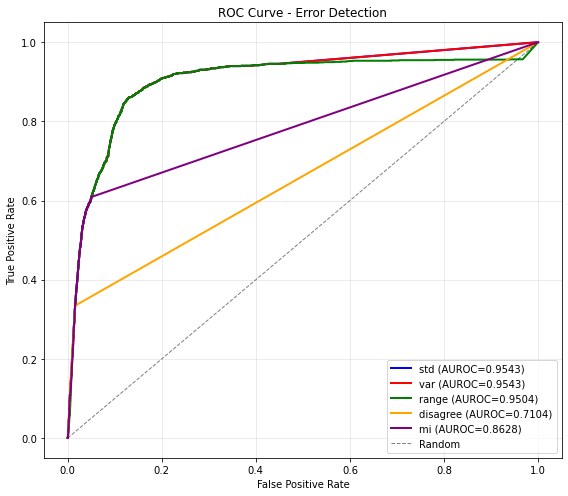

In [12]:
# visualize AUROC
C.Uncertain.plot_auroc_curves(summary)

In [ ]:
# TASK 2: Plaque UQ Visualization (before/after rejection)

In [13]:
CASE_START, CASE_END = 0, 3    # total 14 cases

Case 057 (ESUS 41): 1 side(s)


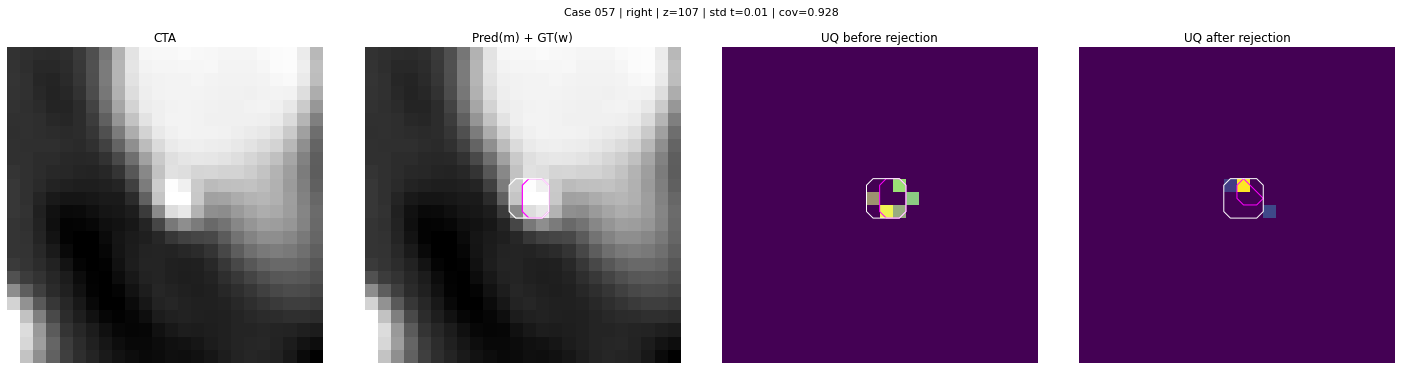

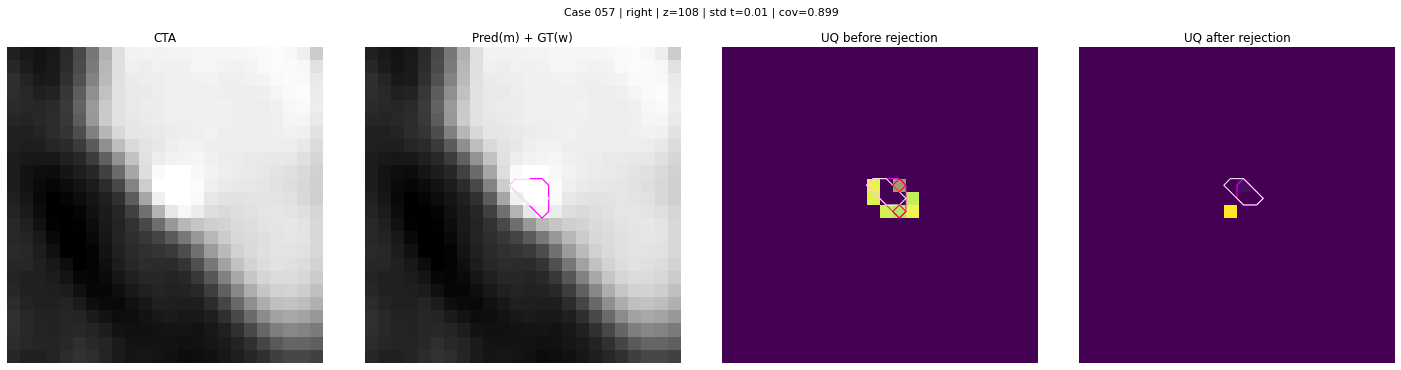

Case 058 (ESUS 71): 2 side(s)


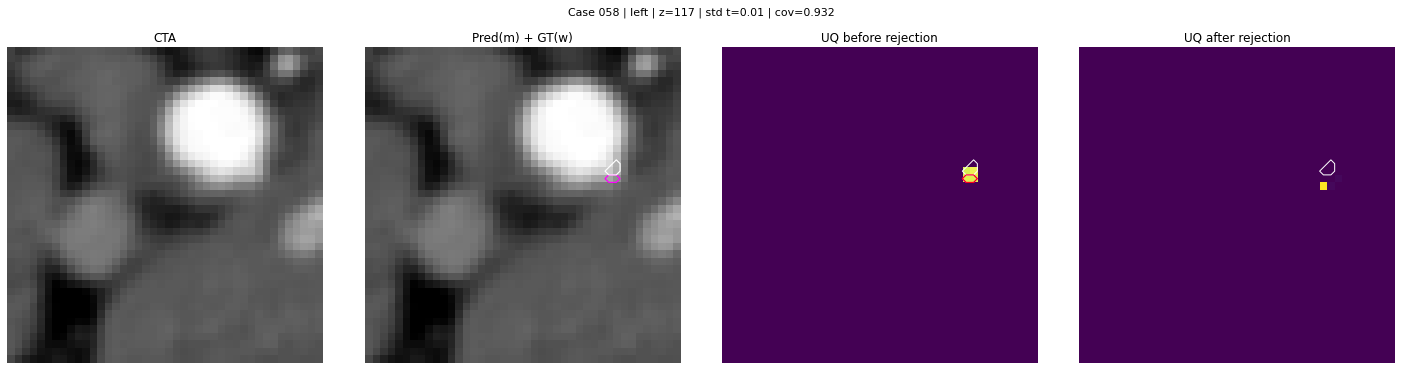

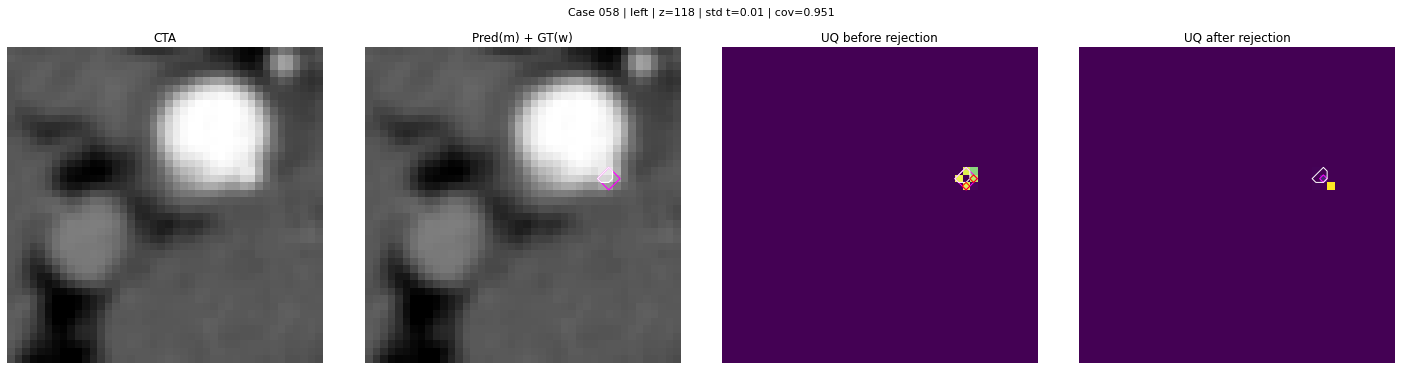

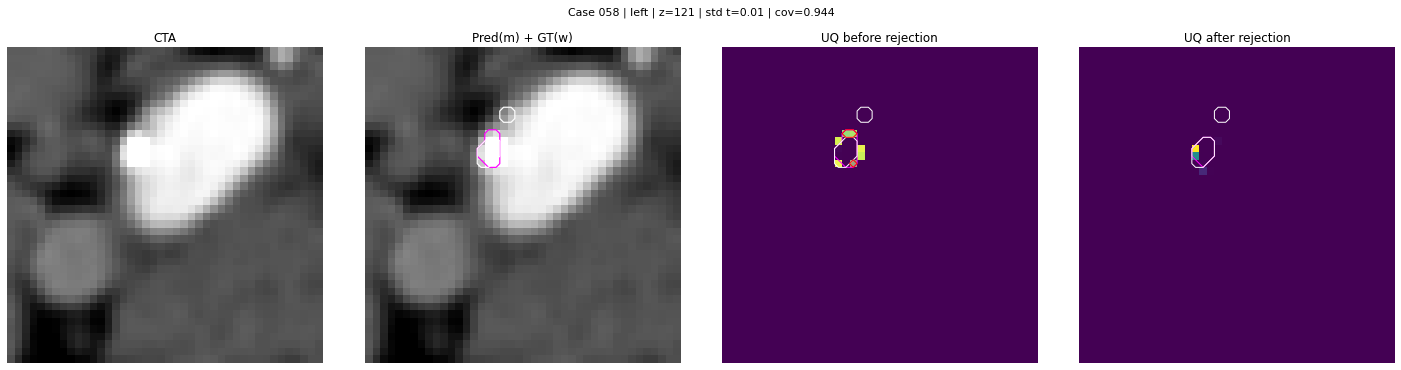

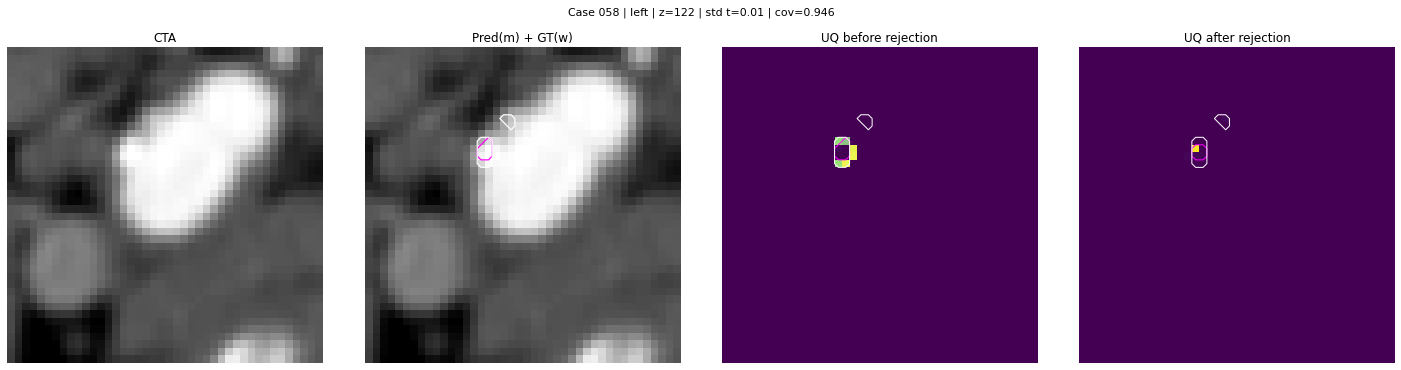

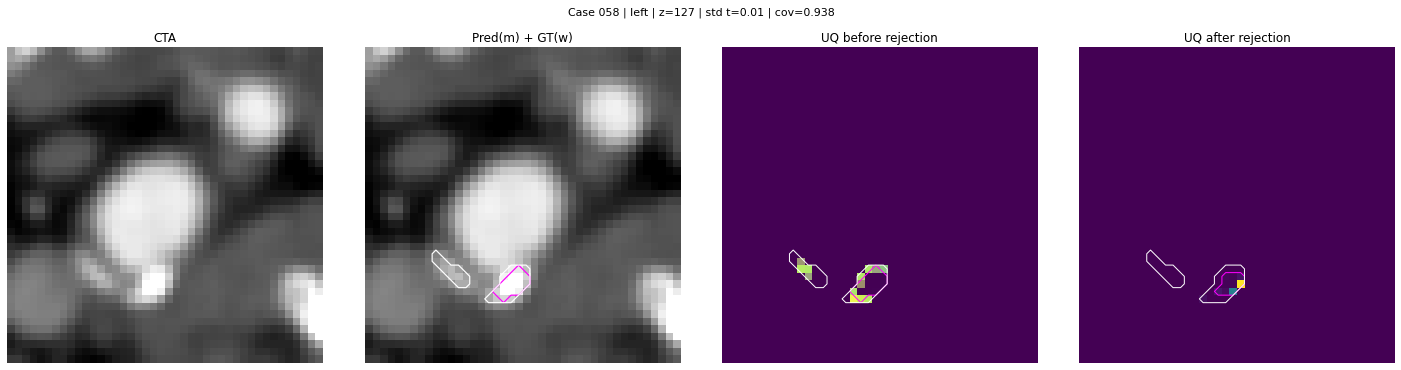

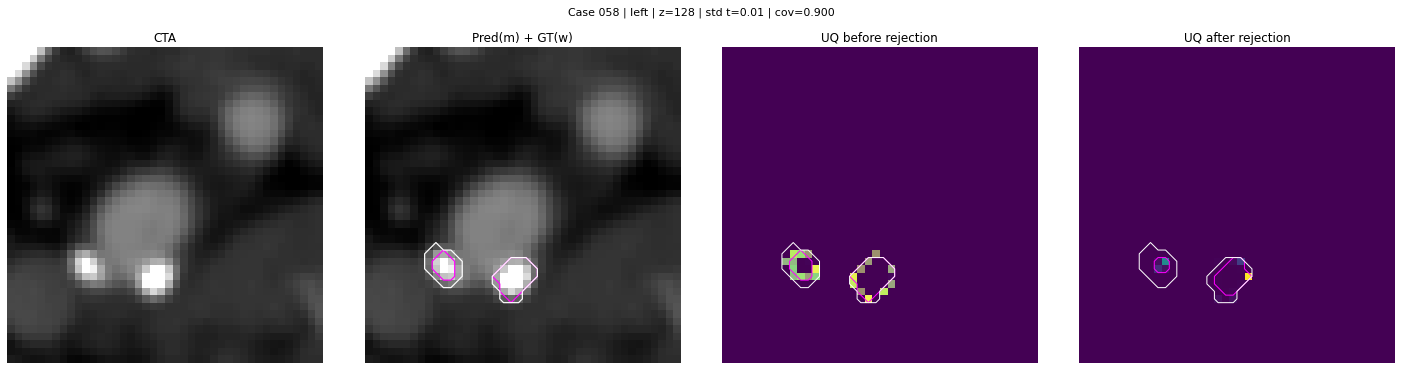

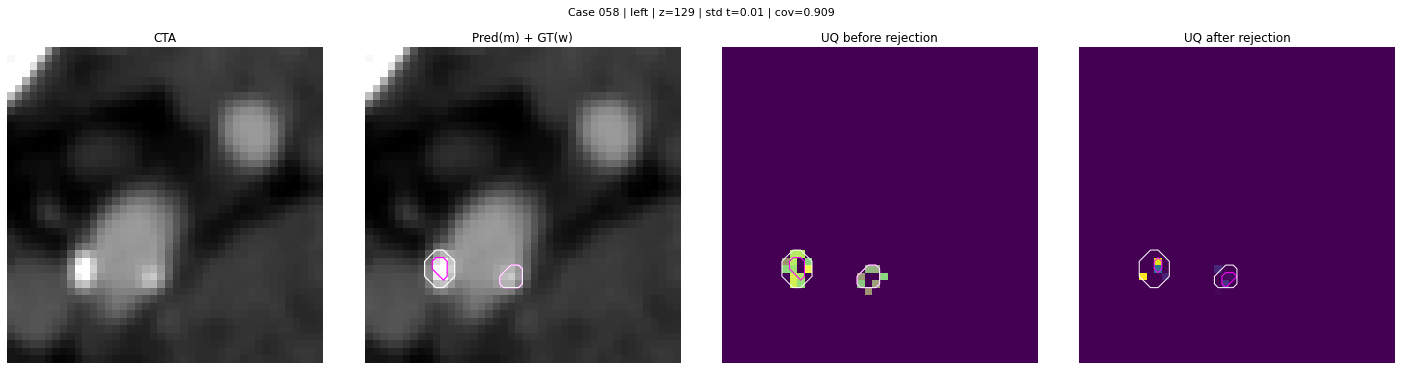

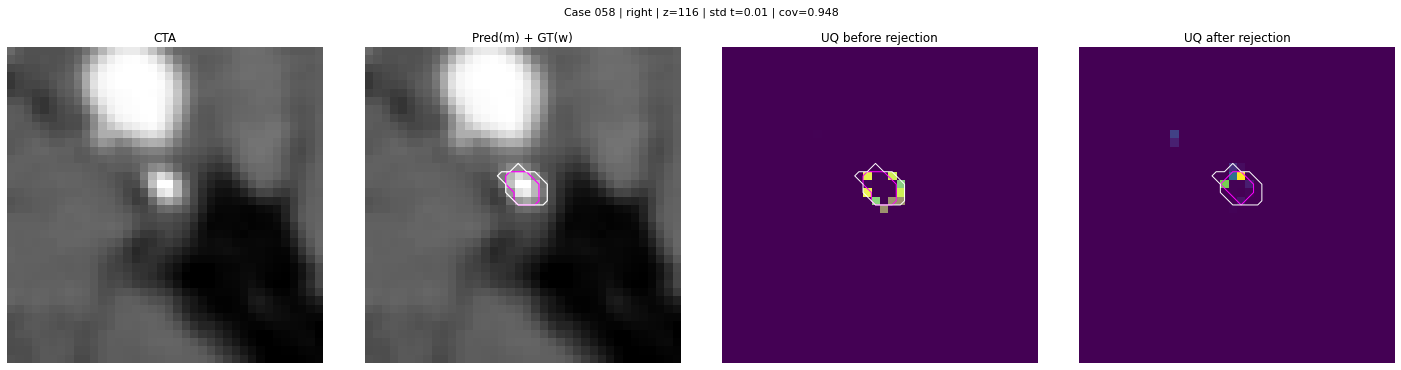

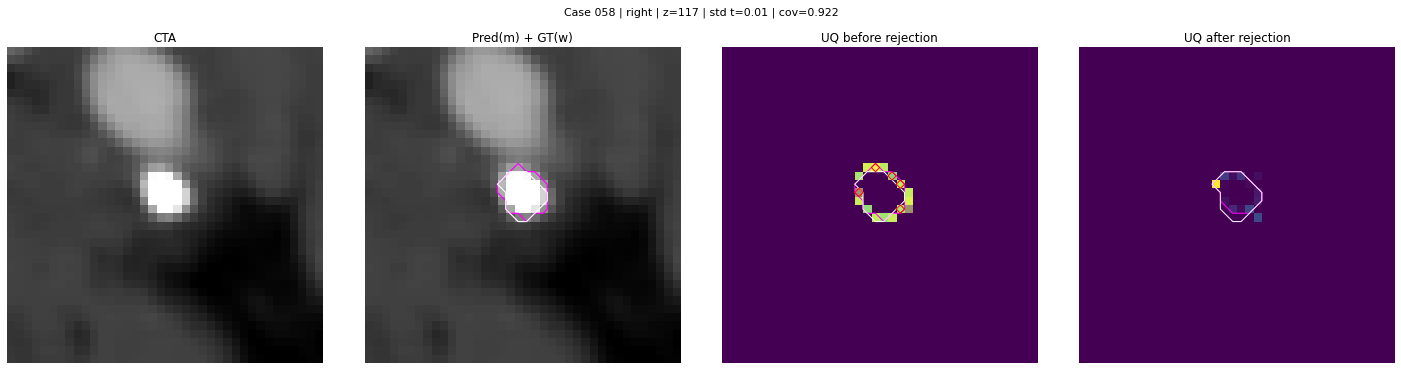

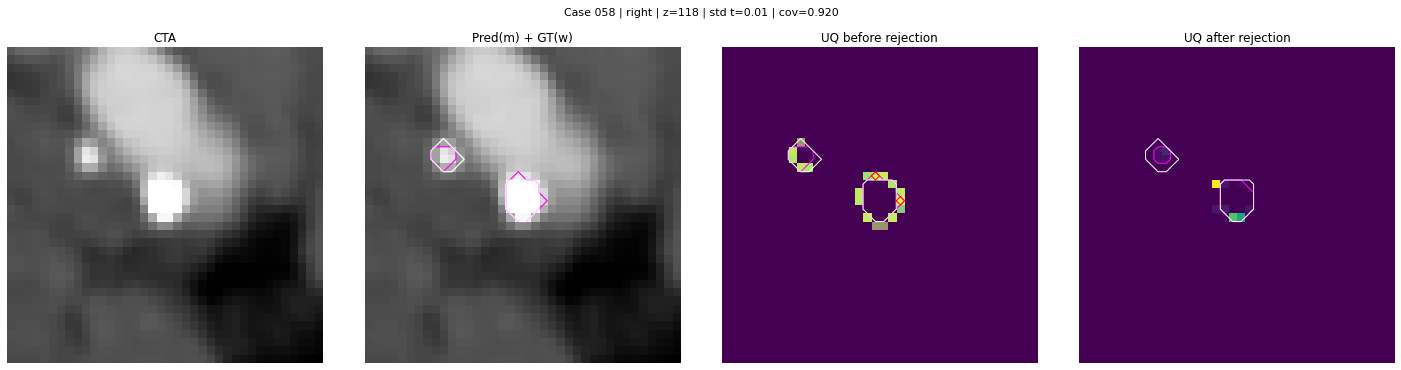

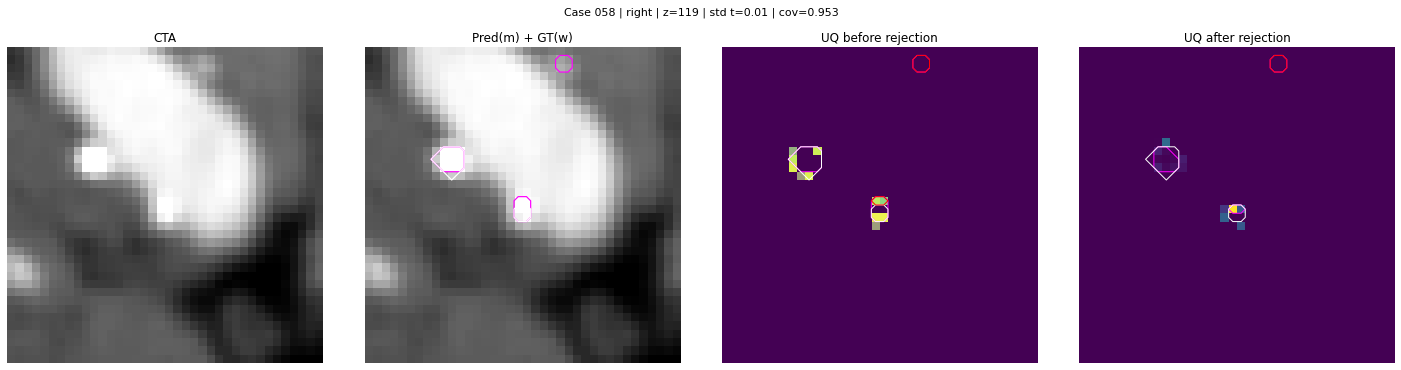

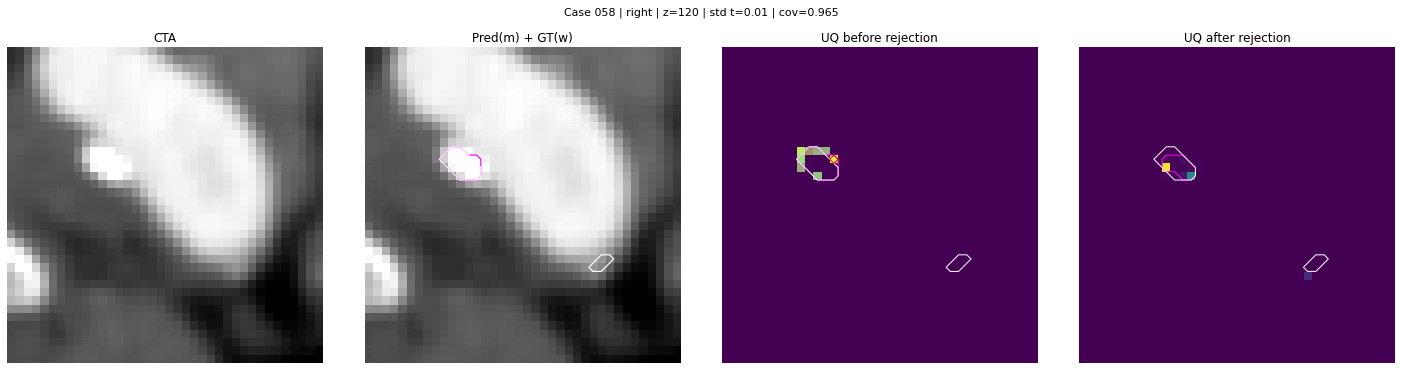

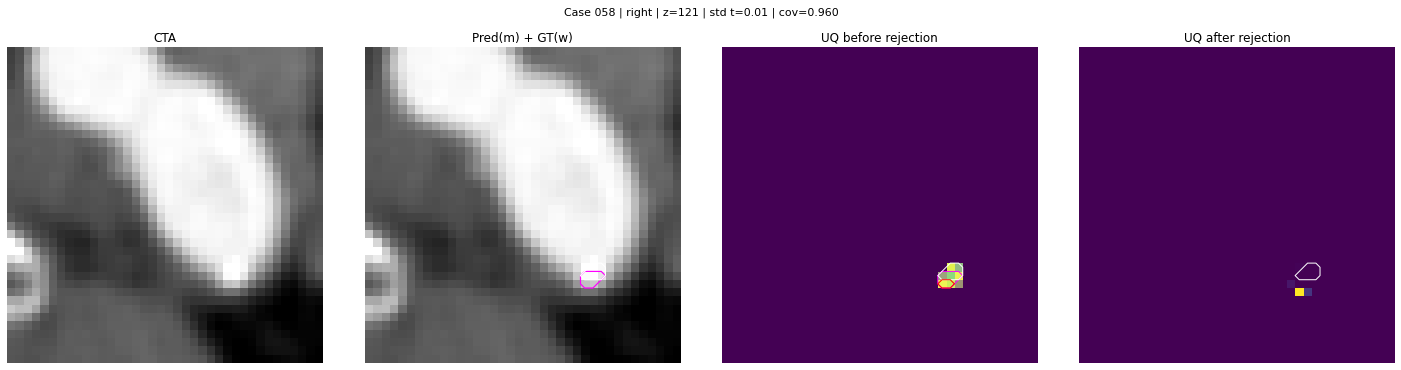

Case 059 (ESUS 84): 2 side(s)


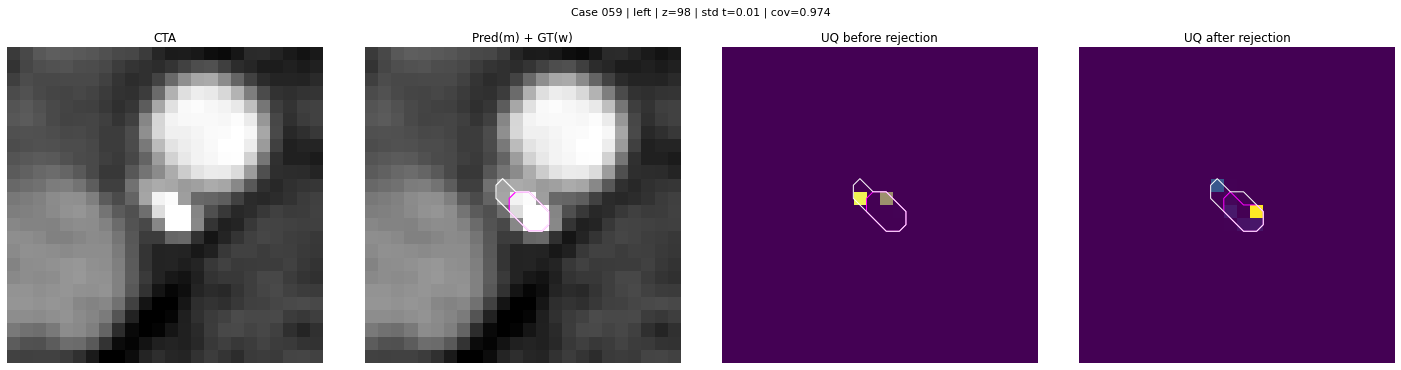

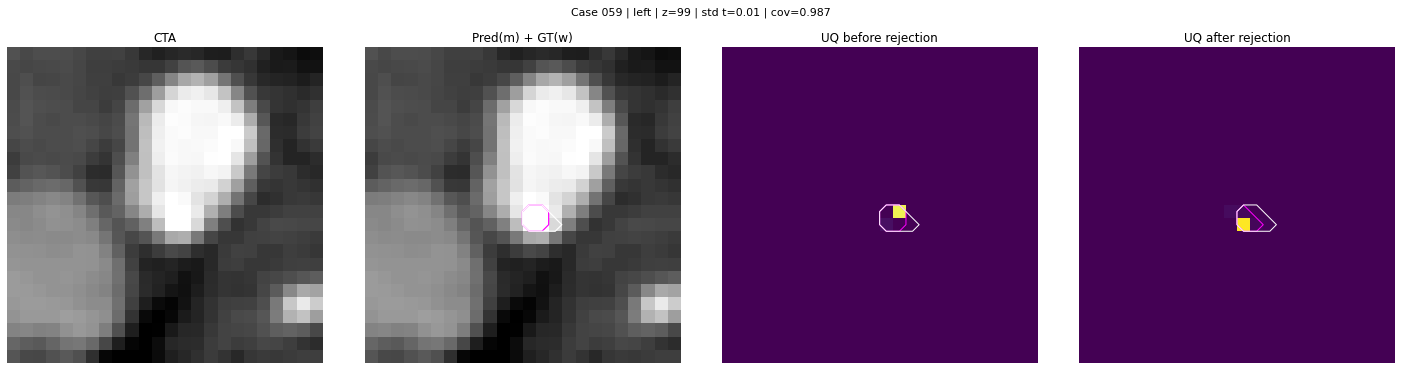

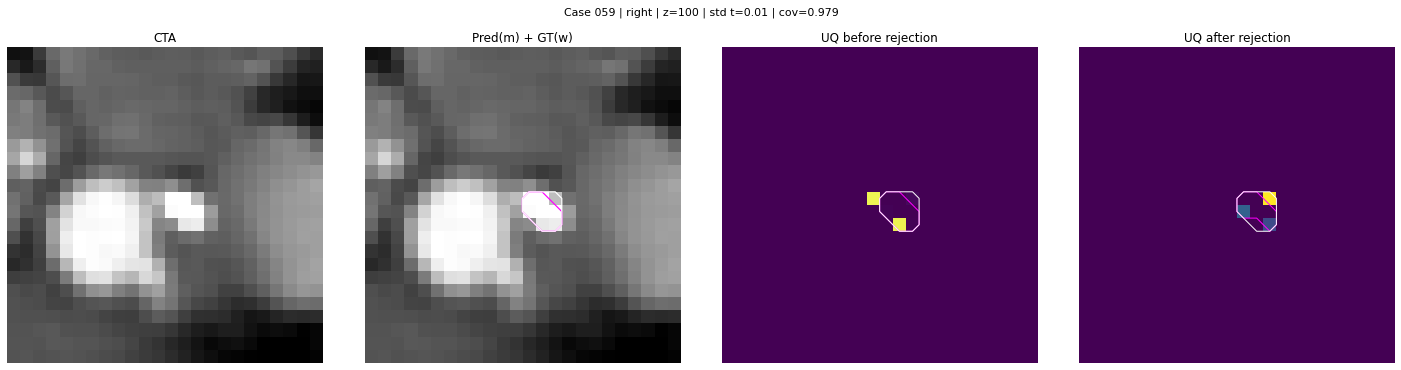

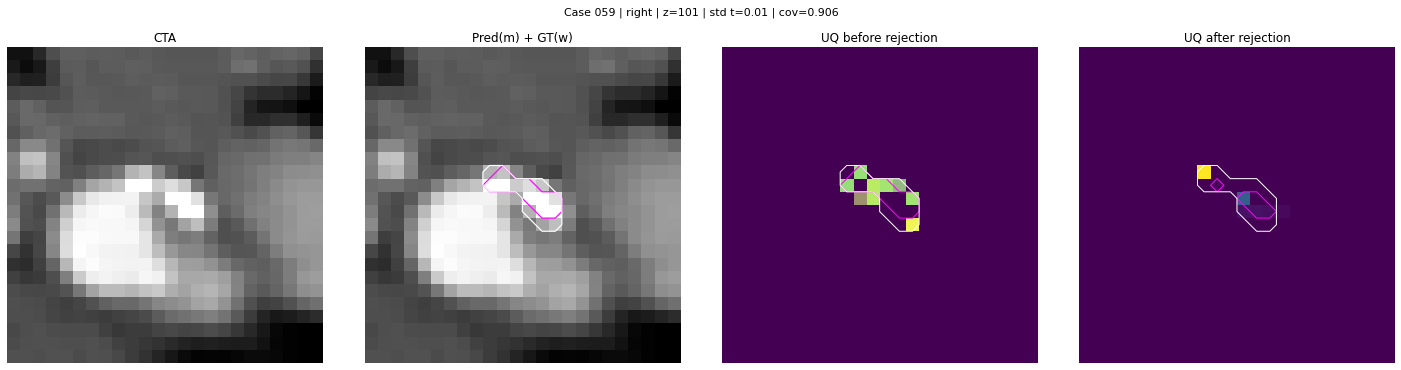

In [14]:
for cid in C.Uncertain.TEST_CASE_IDS[CASE_START:CASE_END]:
    # Load data
    gt = C.Uncertain.read_gt(cid, GT_DIR_TS)
    cta, esus_id = C.Uncertain.read_cta(cid, NNUNET_BASE, ESUS_DIR)
    prob_stack = C.Uncertain.load_prob_stack(cid, TEST_PROB_BASE)
    if gt is None or cta is None or prob_stack is None:
        continue
 
    # UQ maps + rejection
    maps = C.Uncertain.compute_uq_maps(prob_stack)
    pred, eval_mask, uq, reject = C.Uncertain.build_rejection(gt, maps)
 
    # Visualize all slices: before/after rejection
    C.Uncertain.viz_plaque_slices(cid, esus_id, cta, gt, pred, uq, eval_mask, reject)

In [ ]:
# TASK 3: Combined CTA + Inflammogram + Prob + UQ

In [15]:
CASE_START, CASE_END = 0, 3    # total 14 cases

Case 057 (ESUS 41): 1 side(s)


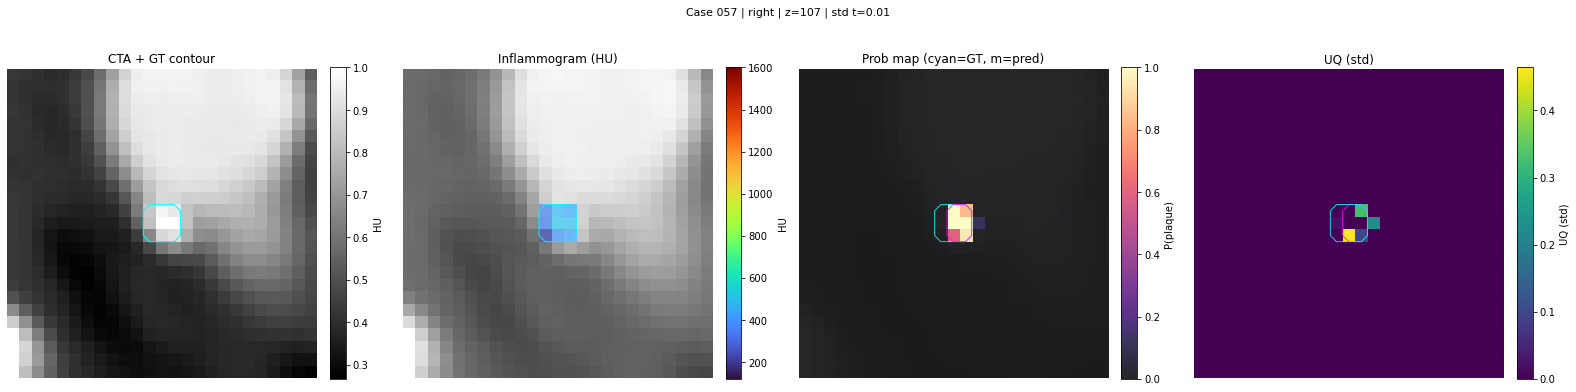

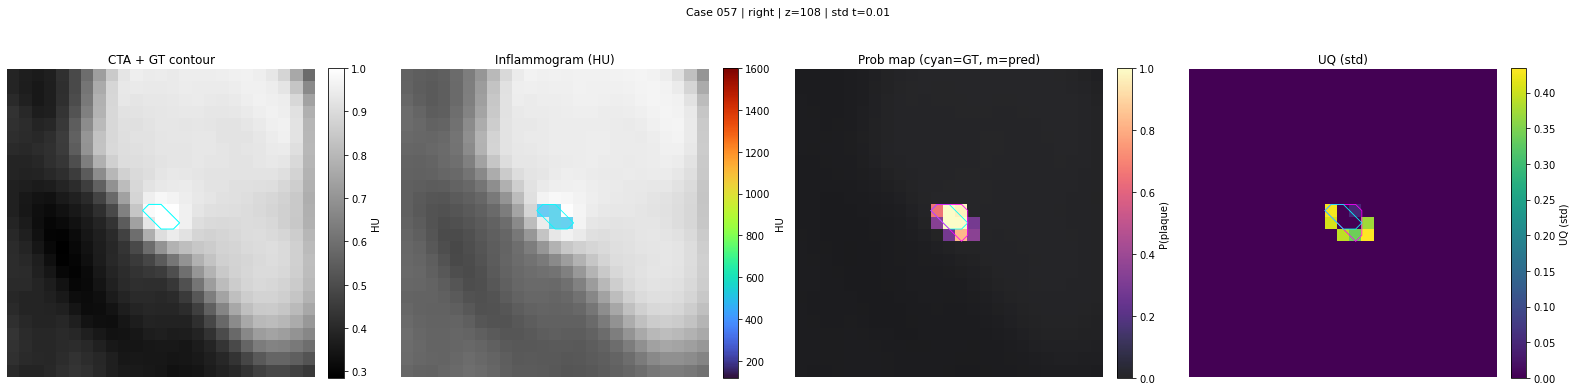

Case 058 (ESUS 71): 2 side(s)


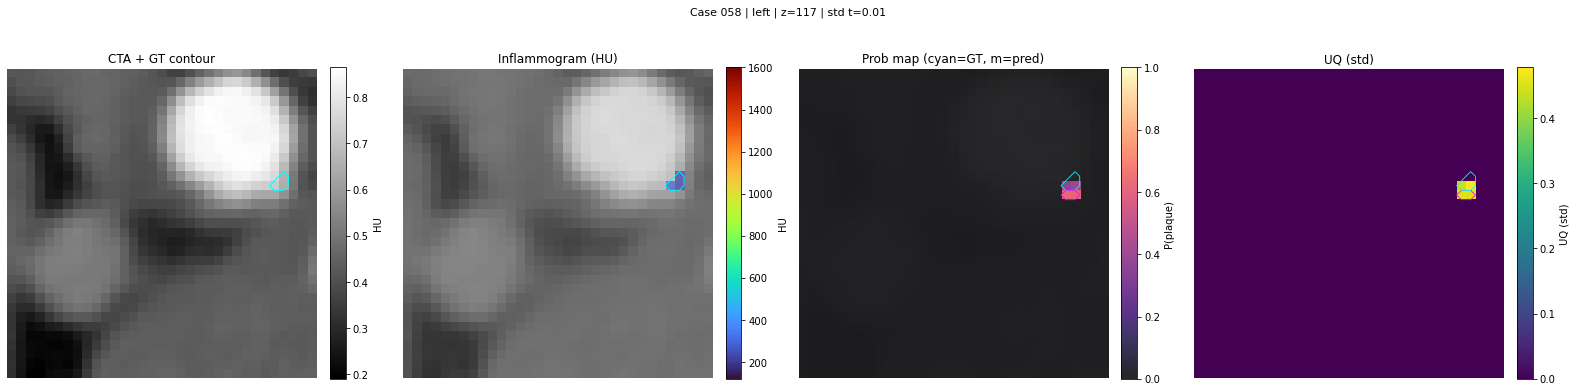

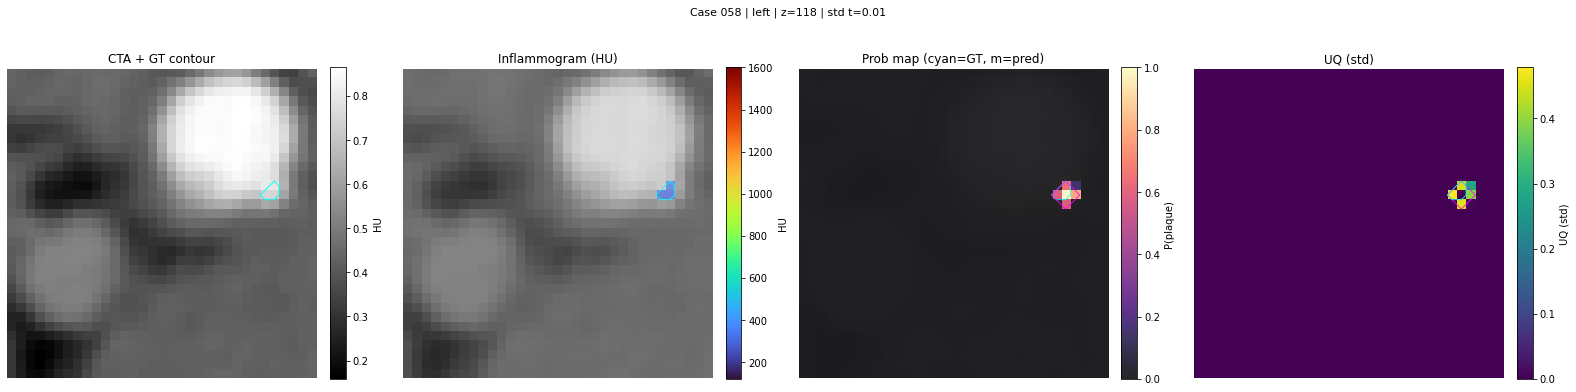

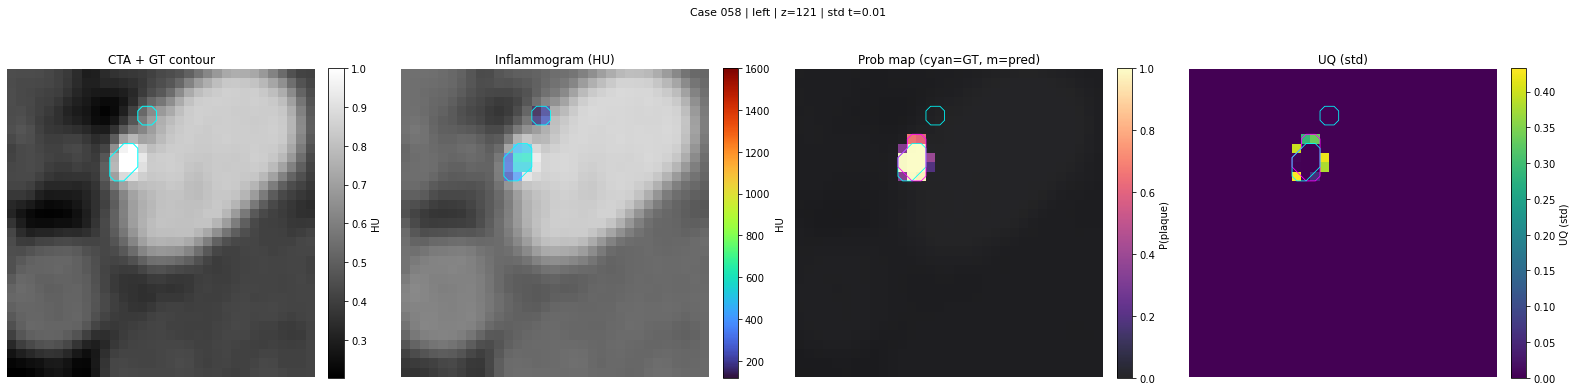

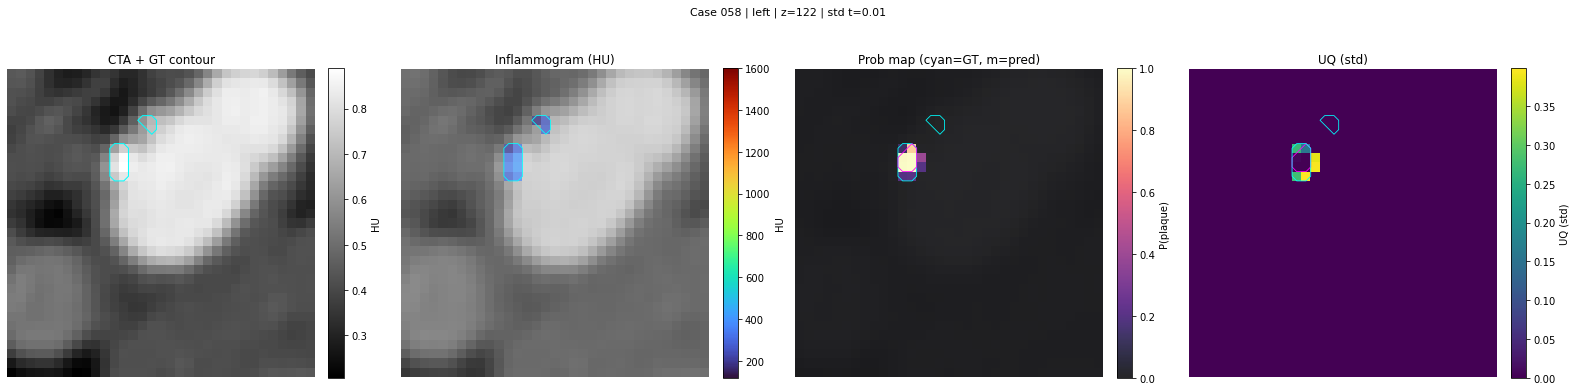

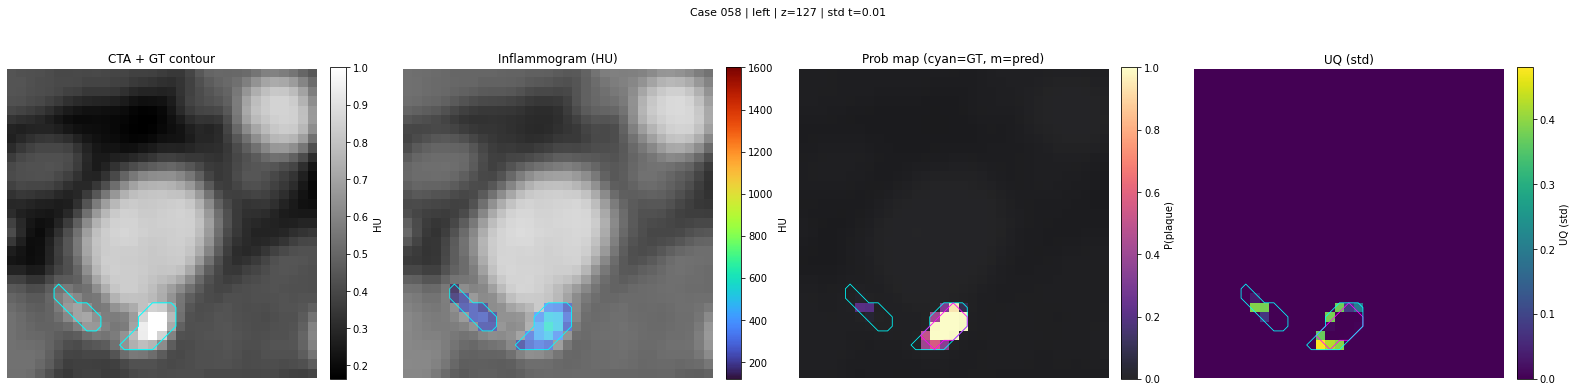

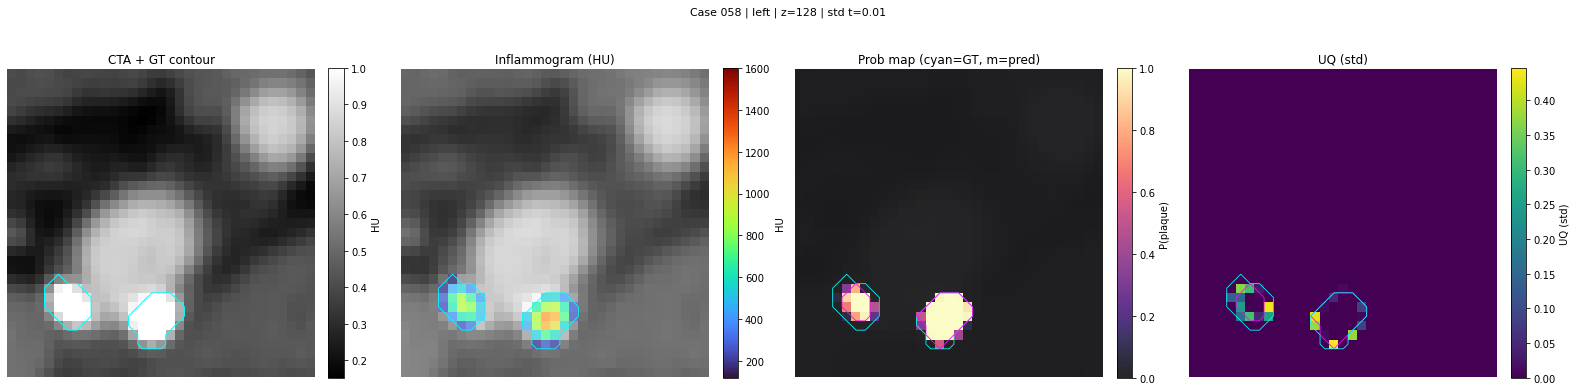

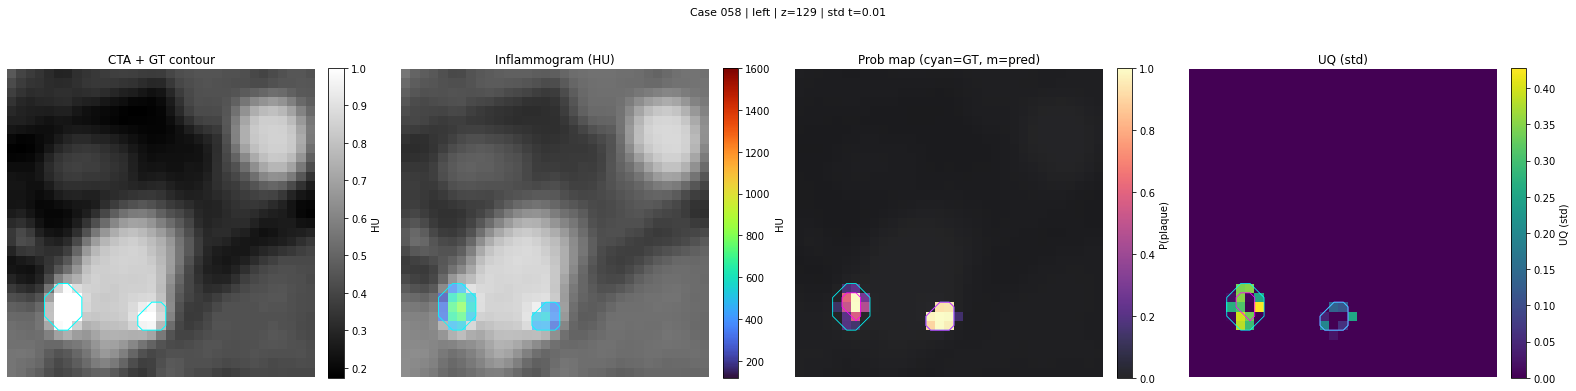

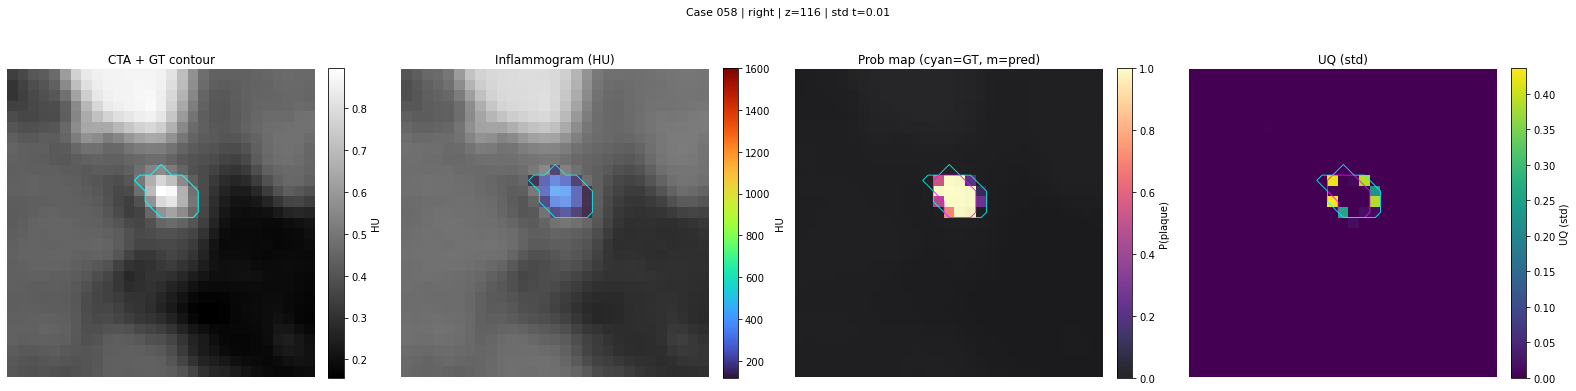

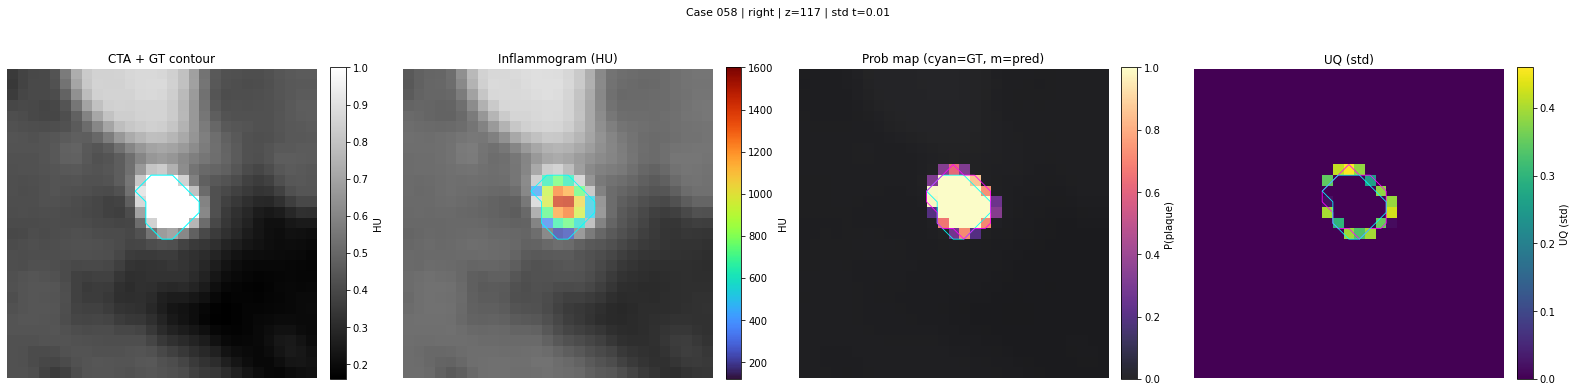

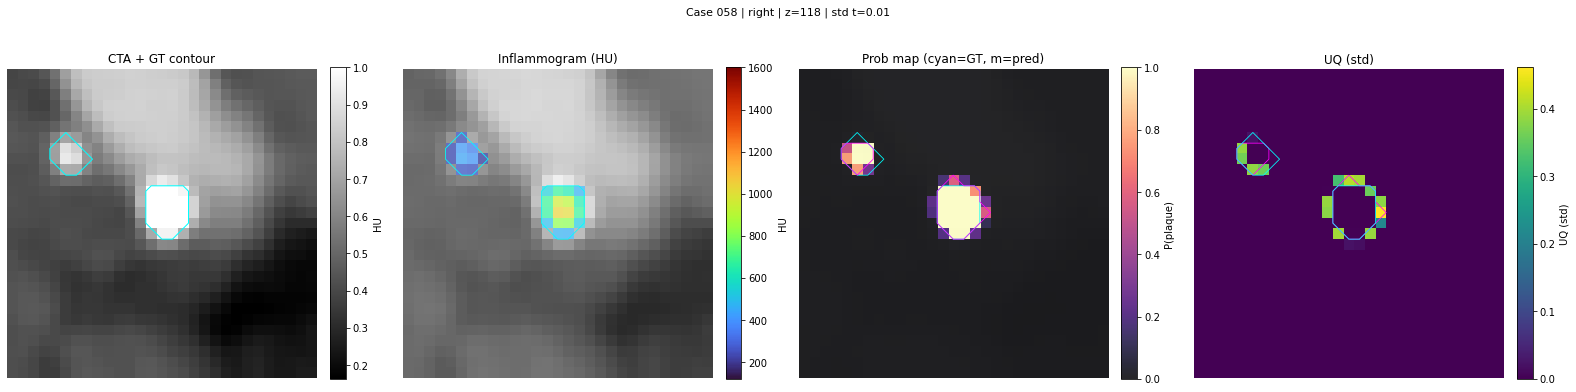

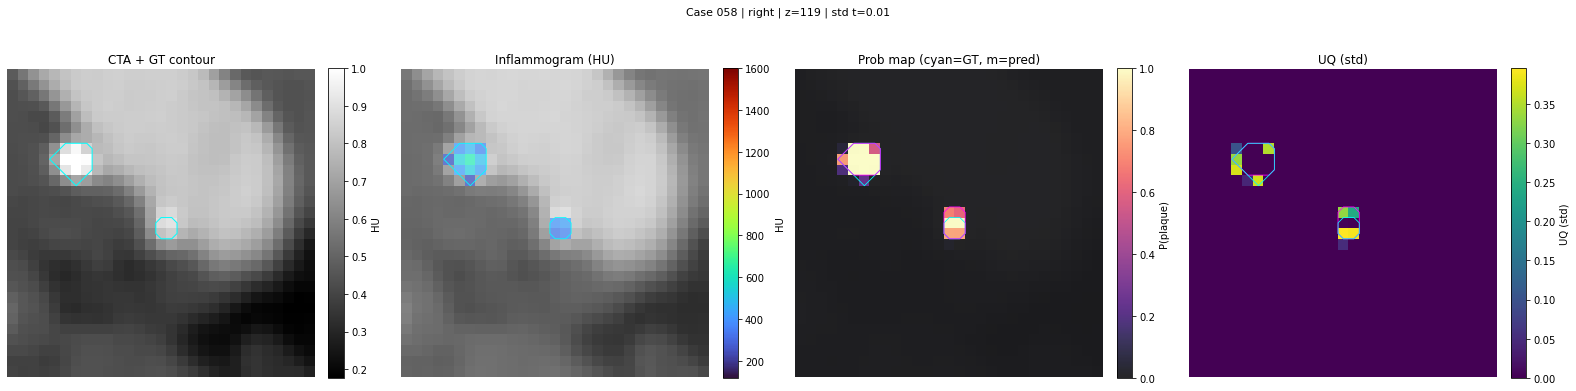

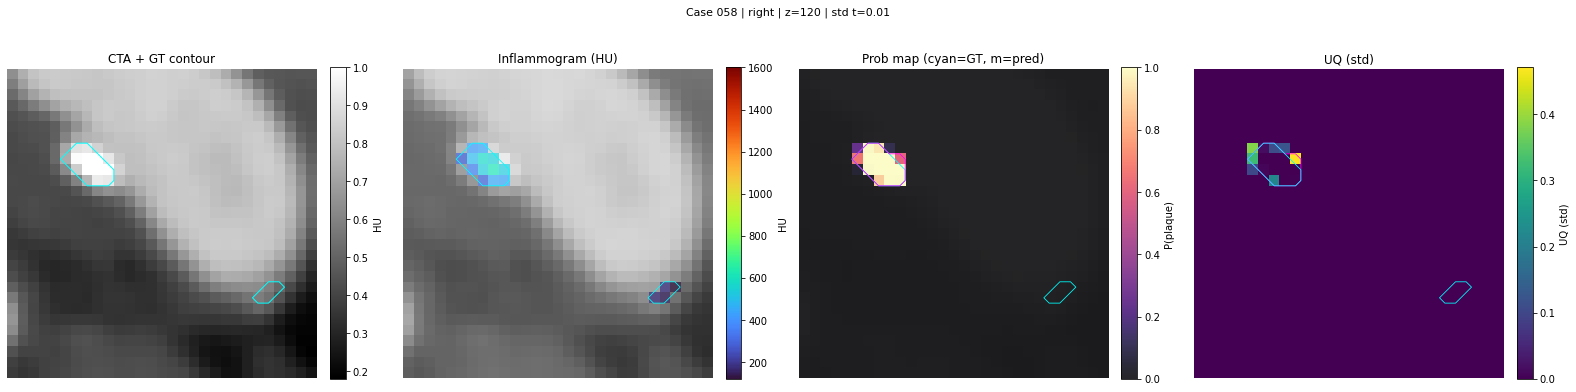

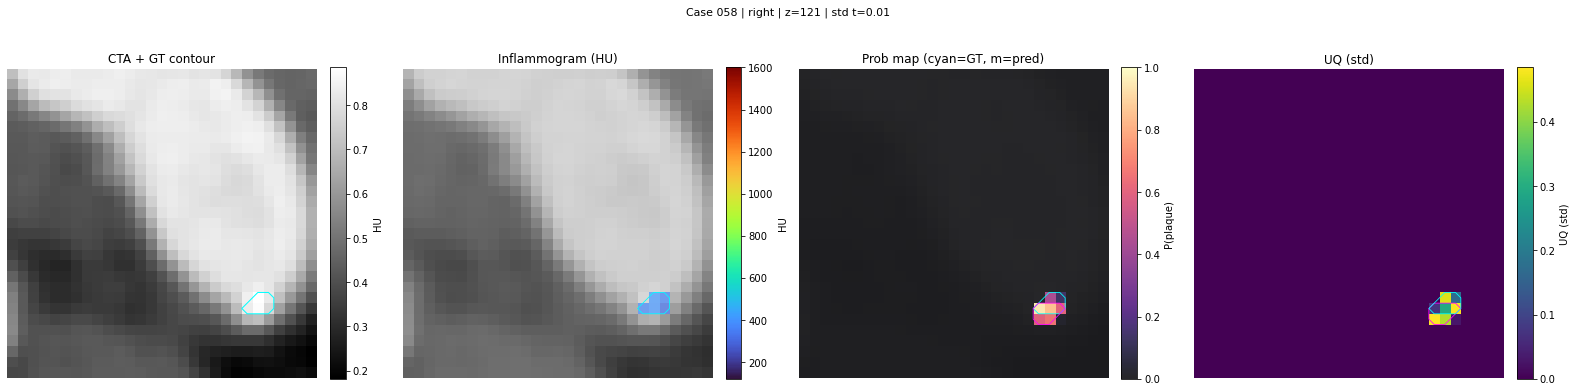

Case 059 (ESUS 84): 2 side(s)


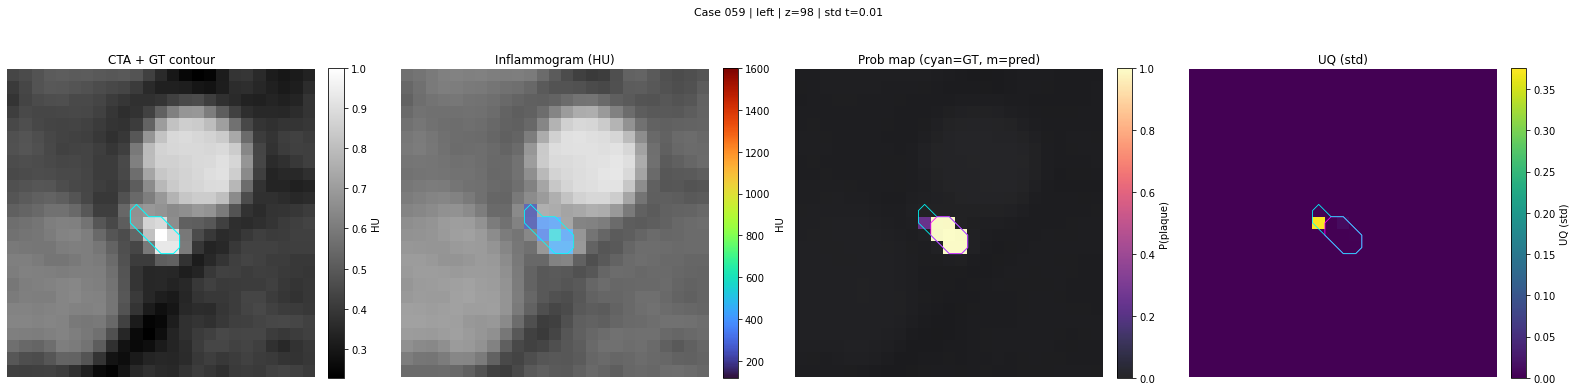

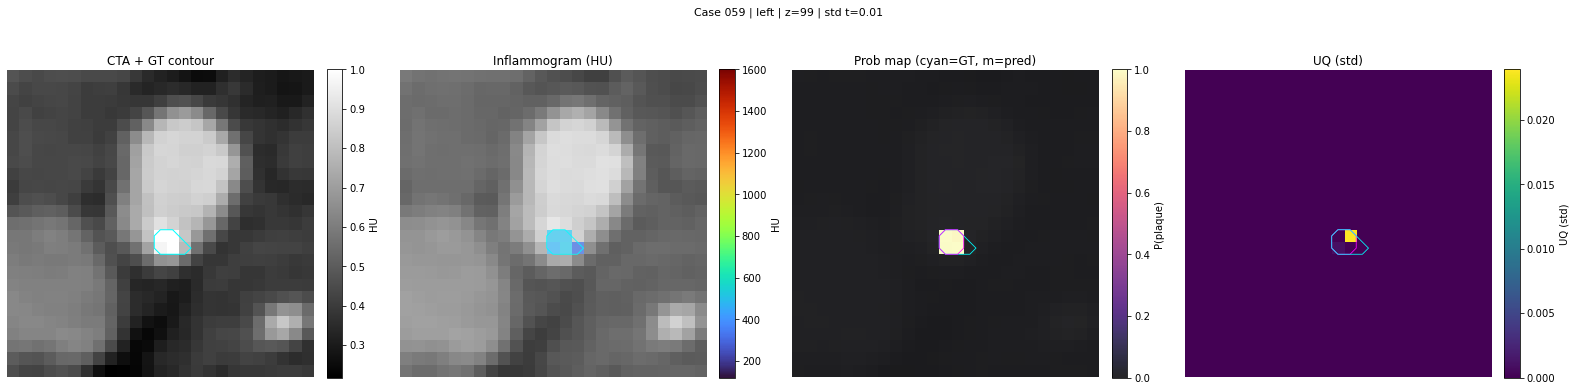

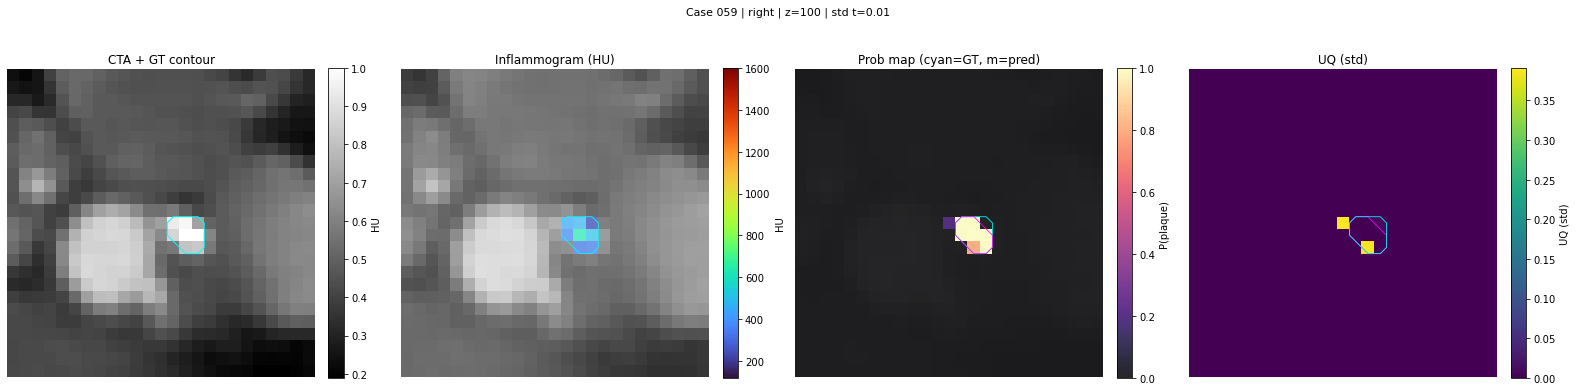

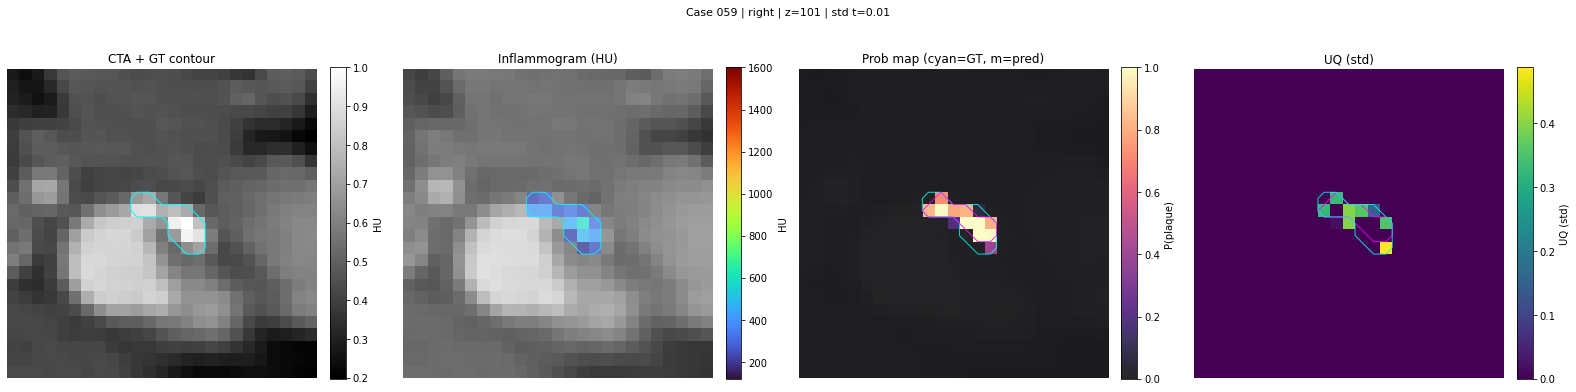

In [16]:
for cid in C.Uncertain.TEST_CASE_IDS[CASE_START:CASE_END]:
    # Load data
    gt = C.Uncertain.read_gt(cid, GT_DIR_TS)
    cta, esus_id = C.Uncertain.read_cta(cid, NNUNET_BASE, ESUS_DIR)
    prob_stack = C.Uncertain.load_prob_stack(cid, TEST_PROB_BASE)
    if gt is None or cta is None or prob_stack is None:
        continue
 
    # UQ maps
    maps = C.Uncertain.compute_uq_maps(prob_stack)
    pred, eval_mask, uq, _ = C.Uncertain.build_rejection(gt, maps)
 
    # Visualize all slices: CTA + HU + prob + UQ
    C.Uncertain.viz_combined_slices(cid, esus_id, cta, gt, pred, maps["p_mean"], uq, eval_mask)

In [ ]:
# TASK 4: Outer Wall Estimation

In [17]:
CASE_START, CASE_END = 0, 1     # total 27 cases


ESUS 57 -> nn062 (test)
  Wall region: 10641 vox


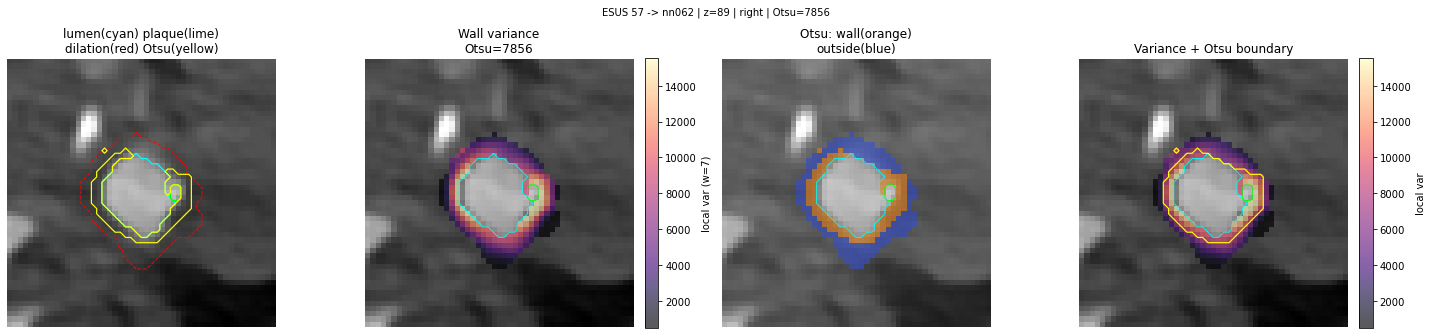

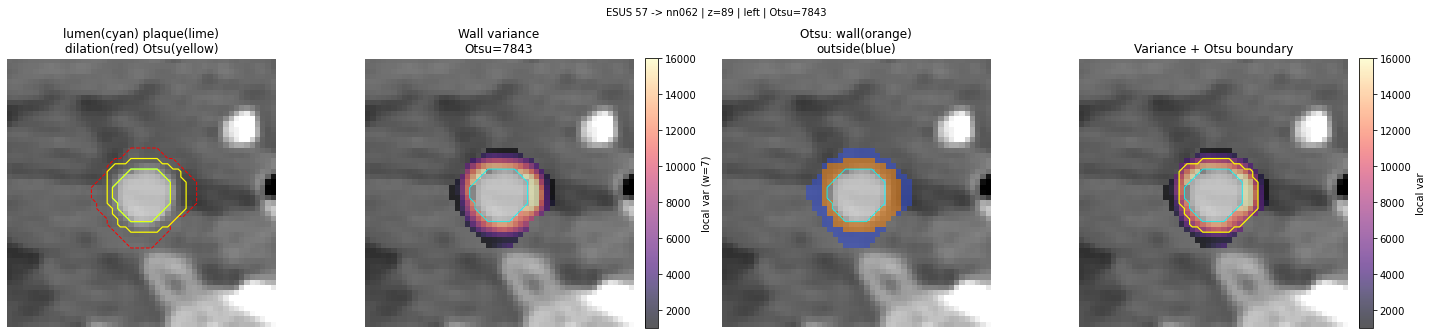

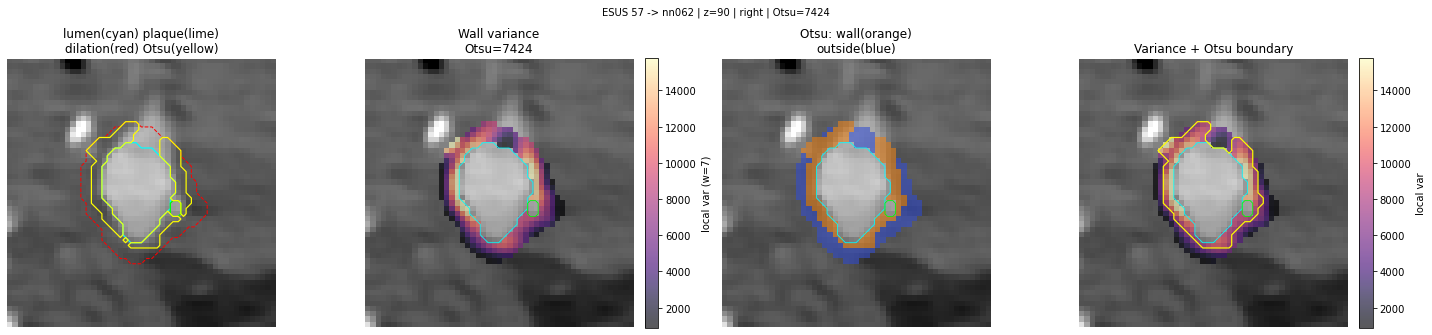

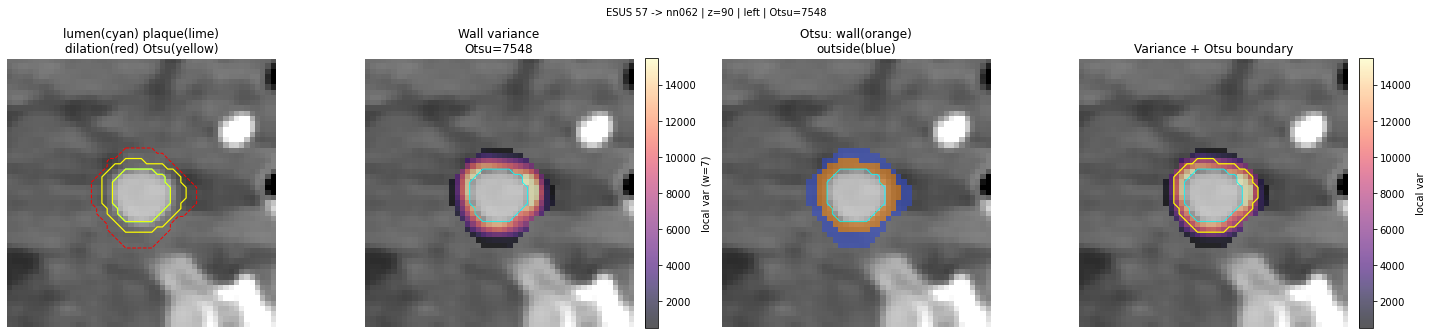

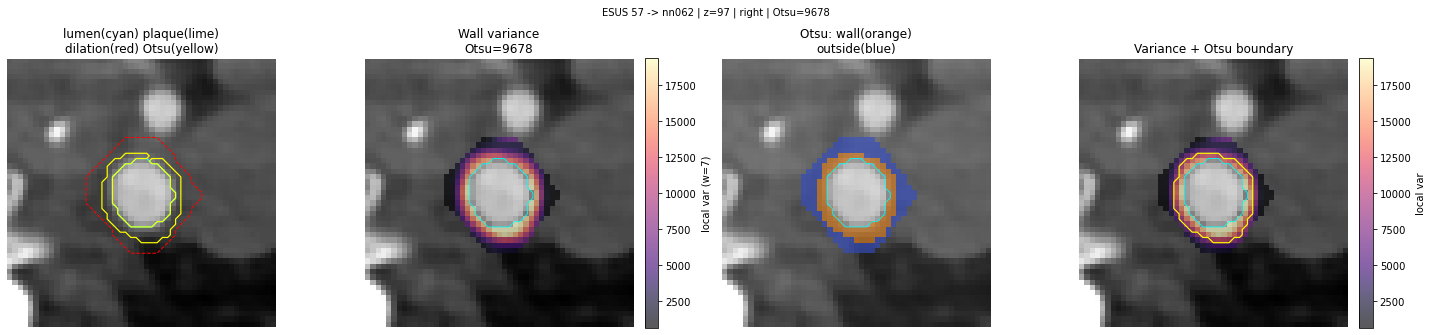

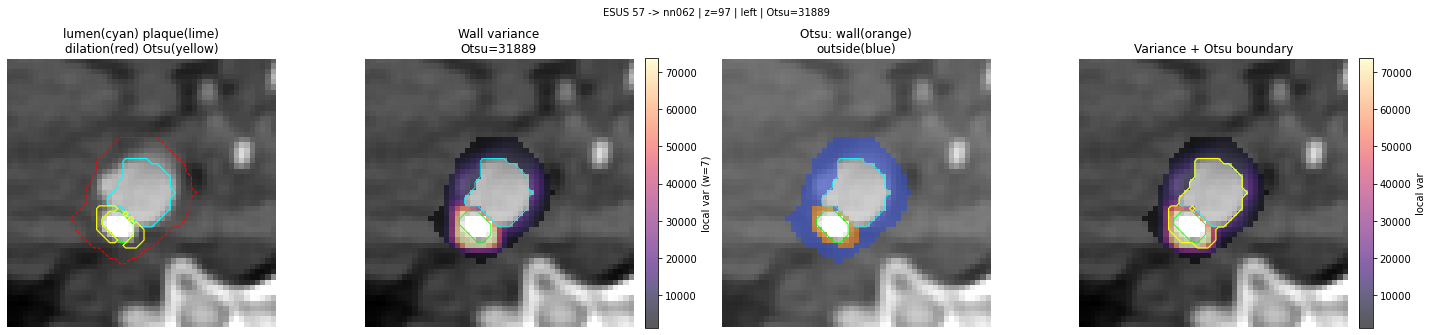

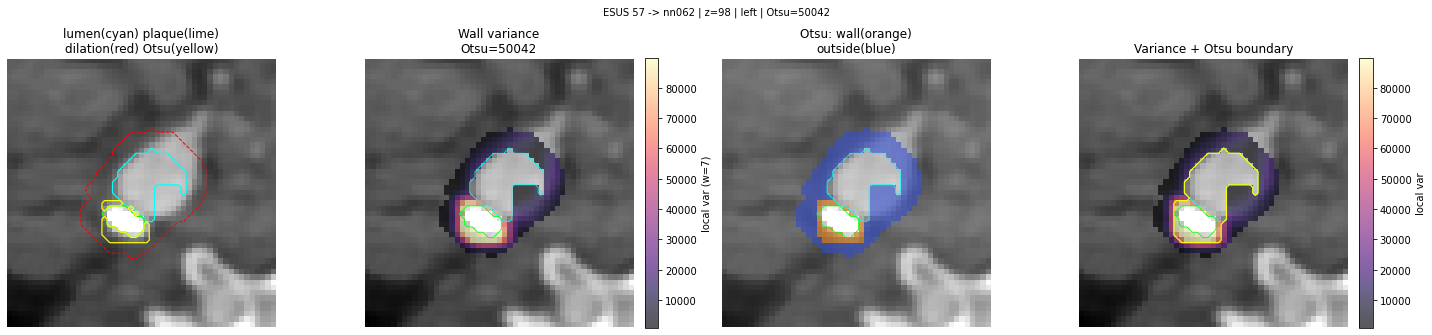

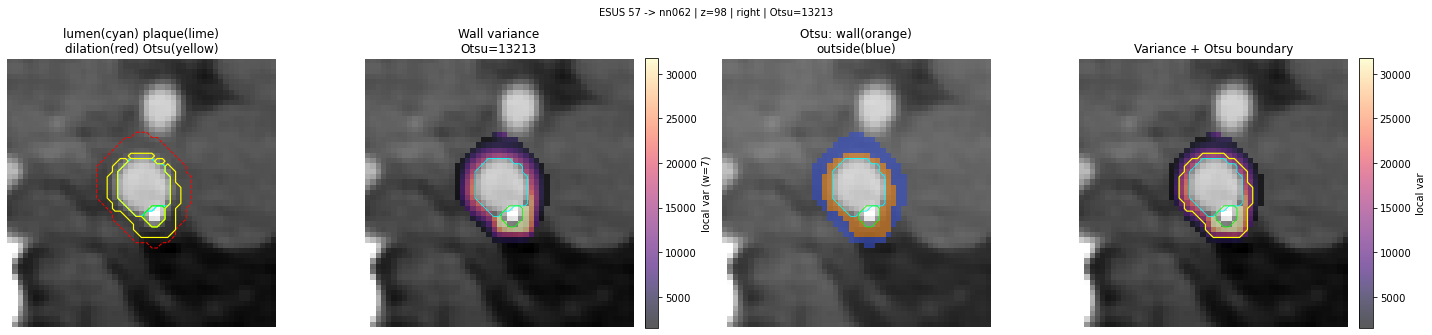

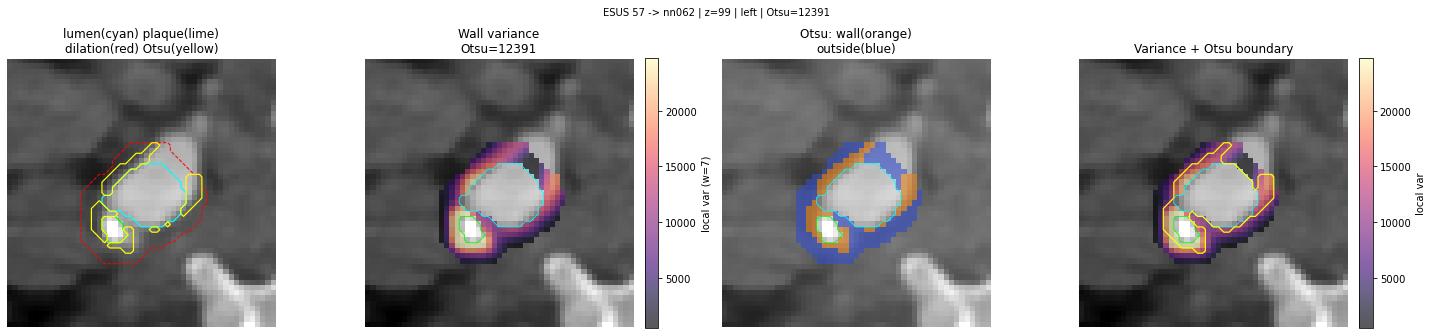

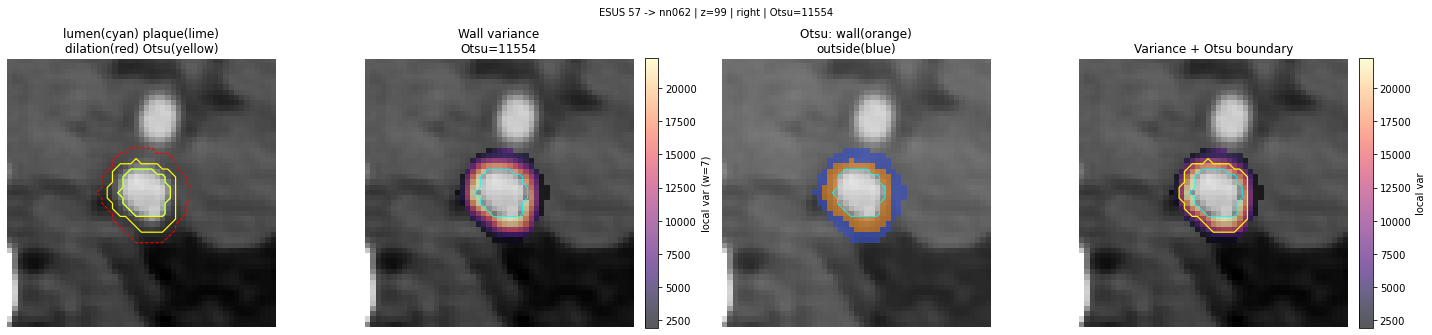

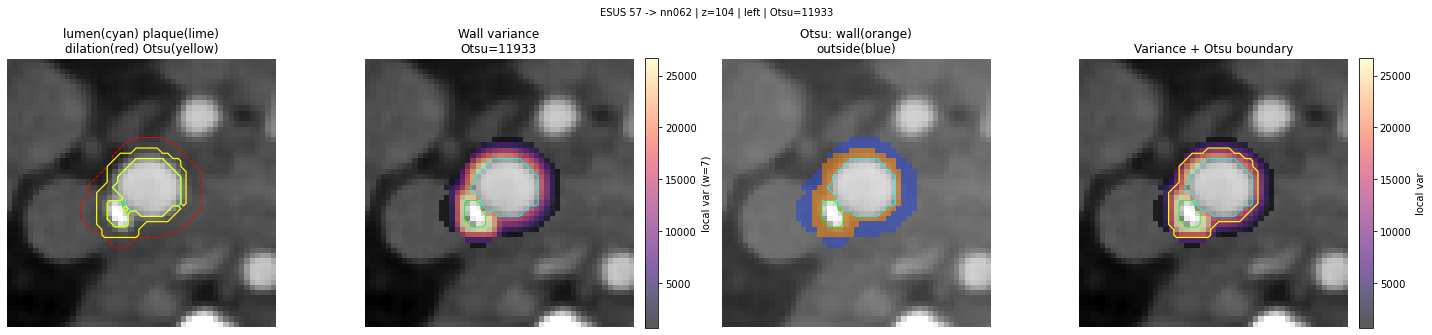

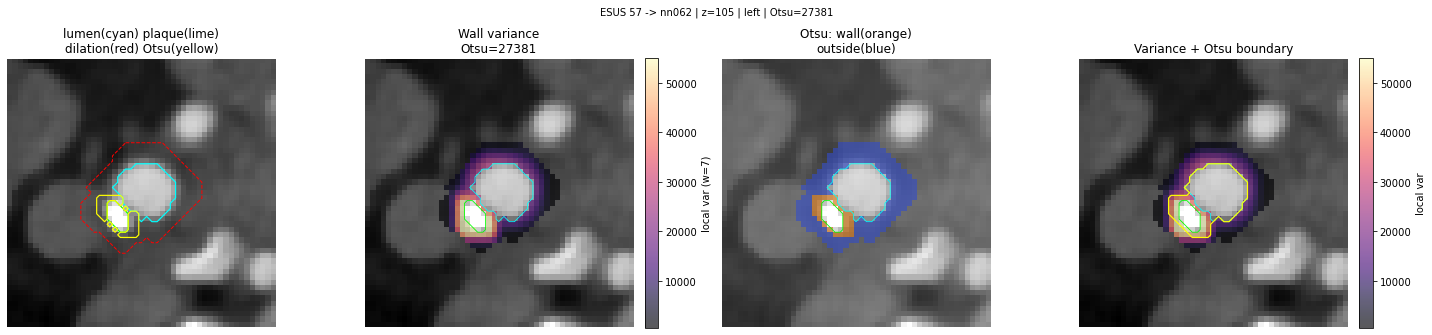

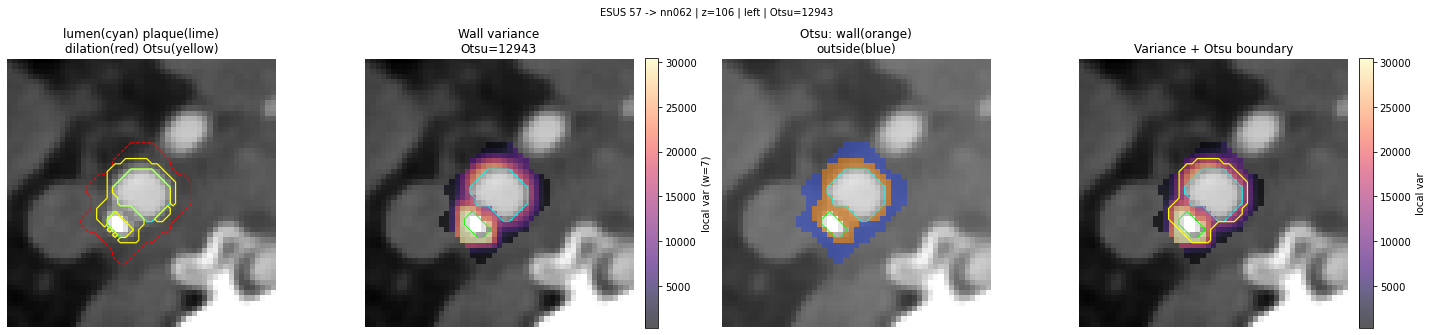

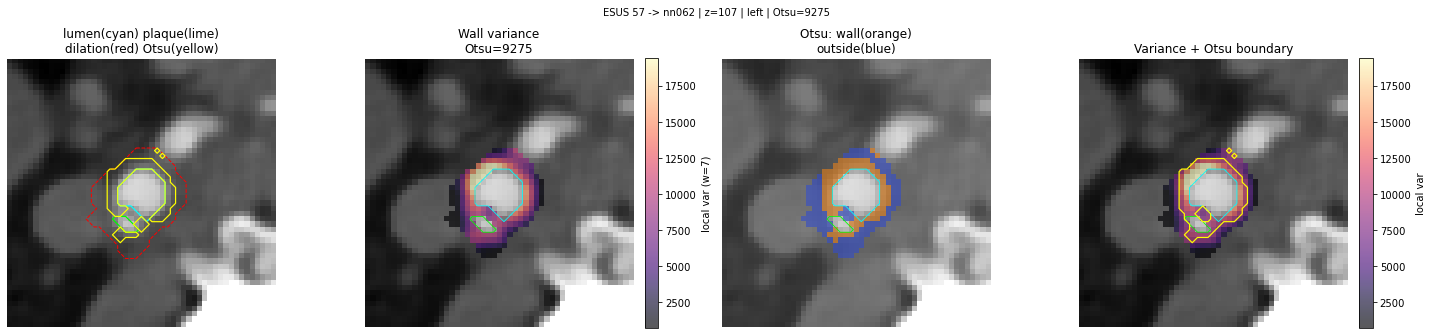

In [18]:
for esus_id, nn_id, split in C.Uncertain.LUMEN_CASES[CASE_START:CASE_END]:
    print(f"\n{'='*50}")
    print(f"ESUS {esus_id} -> nn{nn_id} ({split})")
 
    # Load CT, plaque GT, lumen
    cta, cta_sitk = C.Uncertain.read_wall_cta(esus_id, nn_id, NNUNET_BASE, ESUS_DIR)
    plaque = C.Uncertain.read_plaque_gt(nn_id, NNUNET_BASE)
    lumen = C.Uncertain.read_lumen(esus_id, ELUCID_DIR)
    if cta is None or plaque is None or lumen is None:
        continue
    if cta.shape != plaque.shape or cta.shape != lumen.shape:
        print("  Shape mismatch"); continue
 
    # Isotropic dilation -> wall region
    est_outer = C.Uncertain.isotropic_dilate(
        lumen | plaque, cta_sitk,
        C.Uncertain.ISO_SPACING, C.Uncertain.DILATE_ITERS)
    wall_region = est_outer & ~(lumen | plaque)
    print(f"  Wall region: {wall_region.sum()} vox")
 
    # Per-slice: local variance -> Otsu thresholding -> draw
    C.Uncertain.viz_wall_slices(esus_id, nn_id, cta, lumen, plaque, est_outer, wall_region)